In [2]:
import re
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    AI_DIR = NOTEBOOK_DIR.parent
else:
    AI_DIR = NOTEBOOK_DIR / "ai"

DATASET_DIR = AI_DIR / "dataset"
MODEL_DIR = AI_DIR / "trained_models"

BGL_PATH = DATASET_DIR / "BGL_Preprocessed.parquet"
MODEL_PATH = MODEL_DIR / "logistic_regression_model.pkl"
VECTORIZER_PATH = MODEL_DIR / "tfidf_vectorizer.pkl"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("AI_DIR:", AI_DIR)
print("BGL_PATH:", BGL_PATH)
print("BGL exists:", BGL_PATH.exists())
print("MODEL_PATH:", MODEL_PATH)
print("VECTORIZER_PATH:", VECTORIZER_PATH)

NOTEBOOK_DIR: c:\Users\melis\AI-Log-Analyzer-Pro\ai\notebooks
AI_DIR: c:\Users\melis\AI-Log-Analyzer-Pro\ai
BGL_PATH: c:\Users\melis\AI-Log-Analyzer-Pro\ai\dataset\BGL_Preprocessed.parquet
BGL exists: True
MODEL_PATH: c:\Users\melis\AI-Log-Analyzer-Pro\ai\trained_models\logistic_regression_model.pkl
VECTORIZER_PATH: c:\Users\melis\AI-Log-Analyzer-Pro\ai\trained_models\tfidf_vectorizer.pkl


In [4]:
def clean_log(text):
    text = str(text).lower()
    text = re.sub(r"\([^)]*\)", " ", text)
    text = re.sub(r"0x[a-fA-F0-9]+", " ", text)
    text = re.sub(r"[/\\][^\s]+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
bgl_df = pd.read_parquet(BGL_PATH)

bgl_data = bgl_df[["Clean_Message", "Incident_Type"]].dropna().copy()
bgl_data = bgl_data.rename(columns={
    "Clean_Message": "text",
    "Incident_Type": "label"
})

bgl_data["text"] = bgl_data["text"].apply(clean_log)
bgl_data = bgl_data[bgl_data["text"].str.len() > 2].copy()
bgl_data["source"] = "BGL"

print("Original distribution:")
print(bgl_data["label"].value_counts())

MAX_PER_CLASS = 60000

balanced_parts = []
for label, group in bgl_data.groupby("label"):
    if len(group) > MAX_PER_CLASS:
        group = group.sample(n=MAX_PER_CLASS, random_state=RANDOM_STATE)
    balanced_parts.append(group)

bgl_balanced = pd.concat(balanced_parts, ignore_index=True)

print("\nBalanced distribution:")
print(bgl_balanced["label"].value_counts())
print("\nShape:", bgl_balanced.shape)

In [5]:
bgl_balanced["group_id"] = (
    "bgl__"
    + bgl_balanced["label"].astype(str)
    + "__"
    + bgl_balanced["text"].astype(str)
)

bgl_balanced.head()

,text,label,source,group_id
0,floating point alignment exceptions,Application Failure,BGL,bgl__Application Failure__floating point align...
1,byte ordering exception,Application Failure,BGL,bgl__Application Failure__byte ordering exception
2,idoproxydb hit assert condition assert express...,Application Failure,BGL,bgl__Application Failure__idoproxydb hit asser...
3,double hummer alignment exceptions,Application Failure,BGL,bgl__Application Failure__double hummer alignm...
4,floating point alignment exceptions,Application Failure,BGL,bgl__Application Failure__floating point align...


In [6]:
GENERAL_TEMPLATES = {
    "Memory Error": [
        "ERROR kernel memory parity error detected on DIMM",
        "CRITICAL ECC memory correction exceeded threshold",
        "WARNING corrected memory error reported by mcelog",
        "ERROR cache parity failure detected on CPU",
        "CRITICAL uncorrectable memory error at address",
        "WARNING memory allocation failure detected for process",
        "ERROR out of memory killer terminated service",
        "WARNING JVM heap memory usage exceeded threshold",
        "ERROR database buffer cache memory pressure detected",
        "CRITICAL RAM module failure suspected after repeated ECC events",
    ],
    "Storage/File System": [
        "ERROR disk read failure on device",
        "CRITICAL filesystem mount failed due to corrupted superblock",
        "WARNING disk I/O latency exceeded threshold on volume",
        "ERROR no space left on device while writing logs",
        "CRITICAL RAID array degraded after disk failure",
        "ERROR database write failed due to storage timeout",
        "WARNING filesystem switched to read-only mode after journal error",
        "ERROR backup failed because target volume is unavailable",
        "CRITICAL storage controller reported media error",
        "WARNING inode usage exceeded threshold on root partition",
    ],
    "Network/Communication": [
        "ERROR connection timeout to database host",
        "WARNING packet loss detected on network interface",
        "CRITICAL link down on network interface",
        "ERROR failed to resolve DNS service discovery endpoint",
        "WARNING high latency detected between services",
        "ERROR connection refused by upstream service",
        "WARNING TCP retransmission rate exceeded threshold",
        "ERROR gRPC request failed due to deadline exceeded",
        "CRITICAL message queue broker unreachable",
        "WARNING network socket reset by peer",
    ],
    "System Interrupt": [
        "WARNING unexpected interrupt received on IRQ",
        "ERROR interrupt storm detected on PCI device",
        "INFO timer interrupt drift corrected by kernel",
        "WARNING delayed interrupt processing detected on CPU",
        "ERROR kernel soft lockup detected during interrupt handling",
        "WARNING non-maskable interrupt reported by watchdog",
        "ERROR device driver generated repeated interrupt events",
        "INFO system interrupt handled successfully",
        "WARNING high interrupt rate detected on adapter",
        "ERROR interrupt controller reported inconsistent vector state",
    ],
    "Application Failure": [
        "ERROR application crashed with unhandled exception",
        "CRITICAL segmentation fault in service",
        "ERROR API request failed with HTTP internal server error",
        "WARNING worker process exited unexpectedly",
        "ERROR null pointer exception in authentication module",
        "CRITICAL application startup failed due to missing dependency",
        "ERROR background job failed after maximum retries",
        "WARNING service health check failed for endpoint",
        "ERROR container exited with non-zero status code",
        "CRITICAL runtime exception caused service restart loop",
    ],
    "Power/Thermal Issue": [
        "CRITICAL CPU temperature exceeded safe threshold",
        "WARNING fan speed below expected range",
        "ERROR power supply unit reported voltage instability",
        "CRITICAL thermal shutdown initiated by firmware",
        "WARNING server inlet temperature above threshold",
        "ERROR GPU temperature critical during workload",
        "WARNING cooling zone reported degraded fan performance",
        "CRITICAL rack power distribution unit overload detected",
        "ERROR battery backup unit failure reported",
        "WARNING thermal sensor reading unavailable",
    ],
    "Security/Auth Issue": [
        "WARNING failed login attempt for user admin",
        "CRITICAL multiple authentication failures detected",
        "ERROR unauthorized access attempt blocked by firewall",
        "WARNING invalid API token used for protected endpoint",
        "CRITICAL privilege escalation attempt detected",
        "ERROR SSH login denied due to invalid credentials",
        "WARNING suspicious user session created",
        "CRITICAL brute force login pattern detected",
        "ERROR access denied for restricted database operation",
        "WARNING expired certificate detected during TLS handshake",
    ],
    "Deployment Error": [
        "ERROR deployment failed during container image pull",
        "CRITICAL Kubernetes pod failed to start due to image pull backoff",
        "WARNING configuration reload failed validation",
        "ERROR migration script failed during release deployment",
        "CRITICAL service rollback triggered after failed health checks",
        "ERROR environment variable missing during application startup",
        "WARNING deployment completed with degraded replica availability",
        "ERROR helm upgrade failed due to invalid manifest",
        "CRITICAL CI pipeline failed during production release",
        "WARNING new version failed readiness probe",
    ],
    "Hardware Failure": [
        "CRITICAL hardware failure reported by system board sensor",
        "ERROR PCI device failure detected during bus scan",
        "WARNING hardware watchdog reset occurred unexpectedly",
        "CRITICAL machine check exception reported by CPU",
        "ERROR motherboard sensor reported component failure",
        "WARNING server chassis intrusion sensor triggered",
        "CRITICAL controller failure reported by management interface",
        "ERROR device firmware reported unrecoverable hardware fault",
        "WARNING hardware diagnostic test completed with warnings",
        "CRITICAL system board voltage regulator failure detected",
    ],
    "Other": [
        "INFO scheduled backup completed successfully",
        "INFO user session validated successfully",
        "WARNING configuration reload requested by administrator",
        "INFO health check completed successfully",
        "INFO service restarted successfully",
        "WARNING non-critical service restart completed",
        "INFO cache warmed successfully after deployment",
        "INFO metrics collection completed",
        "WARNING log rotation completed with minor delay",
        "INFO routine maintenance task finished",
    ],
}

rows = []

for label, templates in GENERAL_TEMPLATES.items():
    for template_idx, template in enumerate(templates):
        rows.append({
            "text": clean_log(template),
            "label": label,
            "source": "GENERAL",
            "group_id": f"general__{label}__template_{template_idx}"
        })

general_data = pd.DataFrame(rows)

print(general_data.shape)
print(general_data["label"].value_counts())

(100, 4)
label
Memory Error             10
Storage/File System      10
Network/Communication    10
System Interrupt         10
Application Failure      10
Power/Thermal Issue      10
Security/Auth Issue      10
Deployment Error         10
Hardware Failure         10
Other                    10
Name: count, dtype: int64


In [7]:
combined_data = pd.concat(
    [
        bgl_balanced[["text", "label", "source", "group_id"]],
        general_data[["text", "label", "source", "group_id"]]
    ],
    ignore_index=True
)

combined_data = combined_data.dropna()
combined_data = combined_data[combined_data["text"].str.len() > 2].copy()

print("Combined shape:", combined_data.shape)
print(combined_data["label"].value_counts())

Combined shape: (479399, 4)
label
Application Failure      60010
Deployment Error         60010
Memory Error             60010
Network/Communication    60010
Other                    60010
Storage/File System      60010
System Interrupt         60010
Hardware Failure         58332
Power/Thermal Issue        987
Security/Auth Issue         10
Name: count, dtype: int64


In [8]:
def grouped_split_by_label(df, test_size=0.2, random_state=42):
    train_parts = []
    test_parts = []

    for label, part in df.groupby("label"):
        part = part.copy()

        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_state
        )

        train_idx, test_idx = next(
            gss.split(
                part,
                part["label"],
                groups=part["group_id"]
            )
        )

        train_parts.append(part.iloc[train_idx])
        test_parts.append(part.iloc[test_idx])

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    return train_df, test_df


train_df, test_df = grouped_split_by_label(
    combined_data,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train: (404311, 4)
Test: (75088, 4)

Train labels:
label
Memory Error             59668
Deployment Error         59303
Other                    57587
Network/Communication    55991
Storage/File System      54828
Hardware Failure         53432
System Interrupt         34655
Application Failure      27859
Power/Thermal Issue        980
Security/Auth Issue          8
Name: count, dtype: int64

Test labels:
label
Application Failure      32151
System Interrupt         25355
Storage/File System       5182
Hardware Failure          4900
Network/Communication     4019
Other                     2423
Deployment Error           707
Memory Error               342
Power/Thermal Issue          7
Security/Auth Issue          2
Name: count, dtype: int64


In [9]:
train_groups = set(train_df["group_id"])
test_groups = set(test_df["group_id"])
group_overlap = train_groups.intersection(test_groups)

train_texts = set(train_df["text"])
test_texts = set(test_df["text"])
text_overlap = train_texts.intersection(test_texts)

print("Group overlap:", len(group_overlap))
print("Exact text overlap:", len(text_overlap))

Group overlap: 0
Exact text overlap: 0


In [10]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (404311, 2710)
X_test: (75088, 2710)


In [11]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
pred = model.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))

                       precision    recall  f1-score   support

  Application Failure       1.00      0.78      0.88     32151
     Deployment Error       1.00      1.00      1.00       707
     Hardware Failure       0.97      1.00      0.99      4900
         Memory Error       0.97      0.73      0.83       342
Network/Communication       0.99      1.00      0.99      4019
                Other       0.19      0.90      0.31      2423
  Power/Thermal Issue       0.33      0.14      0.20         7
  Security/Auth Issue       0.22      1.00      0.36         2
  Storage/File System       0.98      1.00      0.99      5182
     System Interrupt       1.00      0.91      0.95     25355

             accuracy                           0.87     75088
            macro avg       0.77      0.85      0.75     75088
         weighted avg       0.97      0.87      0.91     75088



In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svc_model = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

print(classification_report(
    y_test,
    svc_pred,
    zero_division=0
))

c:\Users\melis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


                       precision    recall  f1-score   support

  Application Failure       0.99      1.00      0.99     32151
     Deployment Error       1.00      1.00      1.00       707
     Hardware Failure       0.97      1.00      0.99      4900
         Memory Error       0.98      0.75      0.85       342
Network/Communication       1.00      1.00      1.00      4019
                Other       0.45      0.80      0.58      2423
  Power/Thermal Issue       0.33      0.14      0.20         7
  Security/Auth Issue       1.00      1.00      1.00         2
  Storage/File System       0.98      1.00      0.99      5182
     System Interrupt       1.00      0.91      0.95     25355

             accuracy                           0.96     75088
            macro avg       0.87      0.86      0.85     75088
         weighted avg       0.97      0.96      0.97     75088



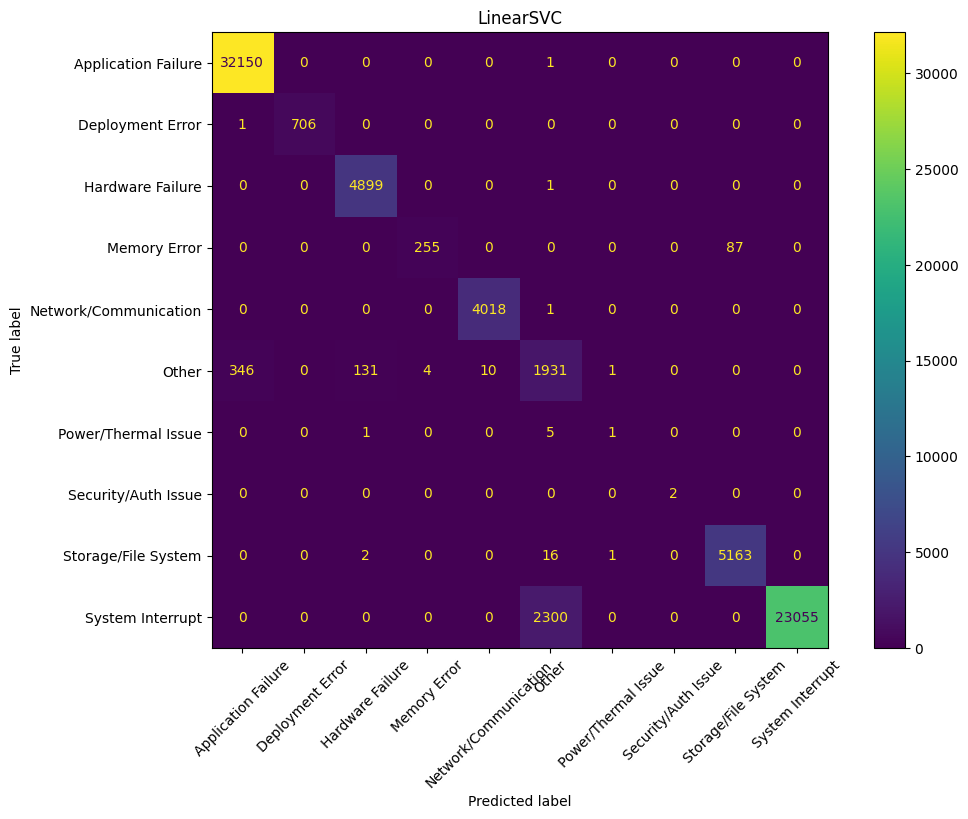

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    svc_pred,
    labels=svc_model.classes_
)

fig, ax = plt.subplots(figsize=(12,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svc_model.classes_
)

disp.plot(ax=ax, xticks_rotation=45)
plt.title("LinearSVC")
plt.show()

In [15]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

sgd_model = SGDClassifier(
    loss="modified_huber",
    penalty="l2",
    alpha=1e-5,
    max_iter=1000,
    tol=1e-3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

print(classification_report(
    y_test,
    sgd_pred,
    zero_division=0
))

                       precision    recall  f1-score   support

  Application Failure       0.99      1.00      1.00     32151
     Deployment Error       1.00      1.00      1.00       707
     Hardware Failure       1.00      1.00      1.00      4900
         Memory Error       0.99      0.72      0.83       342
Network/Communication       1.00      1.00      1.00      4019
                Other       0.37      0.55      0.44      2423
  Power/Thermal Issue       0.83      0.71      0.77         7
  Security/Auth Issue       0.00      1.00      0.00         2
  Storage/File System       0.98      1.00      0.99      5182
     System Interrupt       1.00      0.89      0.94     25355

             accuracy                           0.95     75088
            macro avg       0.82      0.89      0.80     75088
         weighted avg       0.97      0.95      0.96     75088



In [16]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report

cnb = ComplementNB(alpha=0.5)

cnb.fit(X_train, y_train)

pred = cnb.predict(X_test)

print(classification_report(
    y_test,
    pred,
    zero_division=0
))

                       precision    recall  f1-score   support

  Application Failure       0.99      1.00      0.99     32151
     Deployment Error       1.00      1.00      1.00       707
     Hardware Failure       0.94      1.00      0.97      4900
         Memory Error       0.96      0.75      0.84       342
Network/Communication       0.62      1.00      0.77      4019
                Other       0.98      0.59      0.74      2423
  Power/Thermal Issue       0.00      0.00      0.00         7
  Security/Auth Issue       0.00      0.00      0.00         2
  Storage/File System       0.98      1.00      0.99      5182
     System Interrupt       0.99      0.91      0.95     25355

             accuracy                           0.95     75088
            macro avg       0.75      0.72      0.72     75088
         weighted avg       0.97      0.95      0.96     75088



In [17]:
FINAL_MODEL_PATH = MODEL_DIR / "linear_svc_model.pkl"
FINAL_VECTORIZER_PATH = MODEL_DIR / "tfidf_vectorizer.pkl"

joblib.dump(svc_model, FINAL_MODEL_PATH)
joblib.dump(vectorizer, FINAL_VECTORIZER_PATH)

print("Final model saved:", FINAL_MODEL_PATH)
print("Vectorizer saved:", FINAL_VECTORIZER_PATH)

Final model saved: c:\Users\melis\AI-Log-Analyzer-Pro\ai\trained_models\linear_svc_model.pkl
Vectorizer saved: c:\Users\melis\AI-Log-Analyzer-Pro\ai\trained_models\tfidf_vectorizer.pkl


In [1]:
hard_negative_examples = [
    # Network, hardware değil
    ("connection refused by upstream service", "Network/Communication"),
    ("service timeout while calling payment api", "Network/Communication"),
    ("tcp connection reset by peer", "Network/Communication"),
    ("dns resolution failed for internal endpoint", "Network/Communication"),

    # Deployment, application/hardware değil
    ("docker container exited after image pull error", "Deployment Error"),
    ("kubernetes pod failed readiness probe", "Deployment Error"),
    ("helm deployment failed due to invalid manifest", "Deployment Error"),
    ("rollback triggered after failed deployment health check", "Deployment Error"),

    # Security, other değil
    ("permission denied for restricted operation", "Security/Auth Issue"),
    ("invalid api token used for protected endpoint", "Security/Auth Issue"),
    ("ssh authentication failed for root user", "Security/Auth Issue"),
    ("unauthorized access attempt blocked by firewall", "Security/Auth Issue"),

    # Storage, hardware değil
    ("disk write timeout on database volume", "Storage/File System"),
    ("filesystem journal error switched disk to read only mode", "Storage/File System"),
    ("no space left on device while writing logs", "Storage/File System"),
    ("backup failed because target volume unavailable", "Storage/File System"),

    # Application, hardware değil
    ("application crashed with unhandled exception", "Application Failure"),
    ("api returned internal server error", "Application Failure"),
    ("worker process exited unexpectedly", "Application Failure"),
    ("runtime exception caused service restart loop", "Application Failure"),

    # Power/Thermal, hardware değil
    ("cpu temperature exceeded safe threshold", "Power/Thermal Issue"),
    ("fan speed below expected range", "Power/Thermal Issue"),
    ("power supply voltage instability detected", "Power/Thermal Issue"),
    ("gpu temperature critical during workload", "Power/Thermal Issue"),

    # Hardware, sadece gerçekten hardware olanlar
    ("pci device failure detected during bus scan", "Hardware Failure"),
    ("machine check exception reported by cpu", "Hardware Failure"),
    ("system board sensor reported hardware failure", "Hardware Failure"),
    ("firmware reported unrecoverable hardware fault", "Hardware Failure"),

    # Other
    ("scheduled backup completed successfully", "Other"),
    ("health check completed successfully", "Other"),
    ("configuration reload requested by administrator", "Other"),
    ("metrics collection completed successfully", "Other"),
]

hard_rows = []

for i, (text, label) in enumerate(hard_negative_examples):
    for j in range(80):
        hard_rows.append({
            "text": clean_log(text),
            "label": label,
            "source": "HARD_NEGATIVE",
            "group_id": f"hard_negative_{i}"
        })

hard_negative_df = pd.DataFrame(hard_rows)

print(hard_negative_df.shape)
print(hard_negative_df["label"].value_counts())

NameError: name 'clean_log' is not defined